# 06 — The signals as a trading strategy

Notebook 03 asked whether the firm-day signals rank next-session returns.
This one asks what happens to an account that trades them: equity curve,
drawdown, per-year behaviour, and the cost at which the whole thing dies.

Two levers that 03 never touched, and that decide whether its economic null is
real or an artefact of how it traded:

- **Holding horizon.** 03 held for one session and paid ~0.7× turnover a day.
  A horizon-h strategy runs h overlapping tranches, one opened per session,
  each 1/h of gross — so it trades roughly a fifth as much at h=5.
- **Breadth.** 03 traded every name with news (`threshold=0`). Concentrating
  into the tails of each day's cross-section trades less and, if the signal is
  monotone, trades better.

## Declarations — fixed before anything below is computed

- **Universe/spine:** FNSPID news-bearing firm-days, 570 priced symbols.
- **Return:** exact next-exchange-session dense market-adjusted open-to-open,
  from the price archive, so
  positions can be held through sessions with no news. Same convention as
  `ar_open_h1`, extended off the news panel.
- **Positions:** within-session centred rank of the oriented signal, weights
  proportional, gross exposure 1, dollar-neutral by construction.
- **Grid:** 9 signals × horizons {1, 2, 3, 5, 10} × breadth {0.0, 0.5, 0.8}.
- **Costs:** 10 bps per side throughout. Turnover is half-L1, so costs are
  charged on both sides as `2 × turnover × per-side rate`; a cost curve follows.
- **Selection rule (declared now, applied once):** highest **development** net
  Sharpe after costs, among cells with ≥250 sessions and ≥5 average positions;
  ties break on lower turnover. Written to `frozen_spec.json` **before** the
  evaluation block is read.
- **Evaluation:** the corrected run applies the frozen development-selected
  spec without re-selection. One earlier pre-repair read is void because the
  holding-period boundary leaked into January 2020; both reads are disclosed.
- **Inference:** circular block bootstrap on daily net return, block 10, 999
  reps, seed 20260731.

The evaluation block was already opened by `04_surprise`, so it is not a
pristine holdout. It is a chronological evaluation block and the strategy
result inherits that caveat.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import AGGREGATOR_NAMES  # noqa: E402
from final_experiments.lib.evaluate import DEFAULT_SIGNAL_ORIENT  # noqa: E402
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import display_label, diverging_cmap  # noqa: E402
from final_experiments.lib.strategy import (  # noqa: E402
    DEFAULT_BREADTHS,
    DEFAULT_HORIZONS,
    StrategyConfig,
    build_daily_ar_panel,
    cost_curve,
    run_backtest,
    run_frozen_spec,
    select_frozen_spec,
    sweep_development,
    yearly_table,
)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "06_strategy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
SPEC_PATH = OUTPUT_DIR / "frozen_spec.json"

COST_BPS = 10.0
MIN_NAMES = 5
MIN_SESSIONS = 250
MIN_POSITIONS = 5.0

print(f"horizons={DEFAULT_HORIZONS}  breadths={DEFAULT_BREADTHS}  cost={COST_BPS} bps/side")
print(f"split: development ≤ {FROZEN_DEV_END}; evaluation ≥ {FROZEN_EVAL_START}")

horizons=(1, 2, 3, 5, 10)  breadths=(0.0, 0.5, 0.8)  cost=10.0 bps/side
split: development ≤ 2019-12-31; evaluation ≥ 2020-01-01


## 0. Dense return panel

Positions survive sessions on which a name has no news, so returns cannot come
from the news panel. `missing_weight_share` reports any held weight whose
return is unavailable rather than silently treating it as a flat day.

In [2]:
agg = pd.read_parquet(AGG_PATH)
agg["session_date"] = pd.to_datetime(agg["session_date"]).dt.normalize()
symbols = set(agg["symbol"].astype(str))
prices, missing_prices = load_adjusted_open_prices(DEFAULT_PRICE_ZIP, symbols, market_symbol="SPY")
daily_ar = build_daily_ar_panel(prices, market_symbol="SPY")

print(f"signal rows      : {len(agg):,}")
print(f"dense AR rows    : {len(daily_ar):,}  symbols={daily_ar['symbol'].nunique():,}")
print(f"AR sessions      : {daily_ar['session_date'].nunique():,}")
print(f"missing prices   : {missing_prices}")

signal rows      : 715,546
dense AR rows    : 1,810,810  symbols=570
AR sessions      : 3,268
missing prices   : []


## 1. Development sweep

9 signals × 5 horizons × 3 breadth bands = 135 cells, development rows only.
The evaluation block is untouched here.

In [3]:
sweep = sweep_development(
    agg,
    daily_ar,
    signals=AGGREGATOR_NAMES,
    horizons=DEFAULT_HORIZONS,
    breadths=DEFAULT_BREADTHS,
    orients=DEFAULT_SIGNAL_ORIENT,
    cost_bps_per_side=COST_BPS,
    min_names=MIN_NAMES,
)
sweep.to_csv(OUTPUT_DIR / "development_sweep.csv", index=False)
print(f"cells: {len(sweep)}")
display(
    sweep.sort_values("sharpe_net", ascending=False)
    .head(15)[
        [
            "signal", "horizon", "breadth", "sharpe_net", "sharpe_gross",
            "mean_net", "annualized_turnover", "breakeven_bps_per_side",
            "max_drawdown", "mean_positions", "n_sessions",
        ]
    ]
    .round(4)
)

cells: 135


,signal,horizon,breadth,sharpe_net,sharpe_gross,mean_net,annualized_turnover,breakeven_bps_per_side,max_drawdown,mean_positions,n_sessions
68,negative_share,5,0.5,-0.5235,0.1745,-0.0000,1.1455,2.4340,-0.0020,27.6705,88
66,negative_share,2,0.5,-0.9302,0.7977,-0.0000,2.8636,4.0795,-0.0024,11.0682,88
67,negative_share,3,0.5,-1.3041,-0.4464,-0.0000,1.9091,-4.7838,-0.0032,16.6023,88
134,decayed_state,10,0.8,-1.6932,-0.2496,-0.0002,23.1328,-1.7292,-0.3923,246.1096,2263
119,attention_log_n,10,0.8,-1.9324,-0.0874,-0.0002,23.3971,-0.4736,-0.3613,274.8294,2263
129,decayed_state,10,0.5,-2.0024,-0.2680,-0.0002,21.4475,-1.5451,-0.3639,400.6765,2263
44,median_continuous,10,0.8,-2.0176,0.0463,-0.0002,23.6555,0.2243,-0.3431,287.6659,2263
59,trimmed_mean,10,0.8,-2.1213,-0.0841,-0.0002,23.6805,-0.4129,-0.3604,289.4278,2263
29,mean_continuous,10,0.8,-2.1441,-0.1062,-0.0002,23.6813,-0.5212,-0.3634,289.4755,2263
14,mean_hard_label,10,0.8,-2.2635,-0.0447,-0.0002,22.4548,-0.2015,-0.3404,315.6505,2263


### Where the levers actually bite

Net Sharpe as a surface over horizon and breadth. If the h=1 economic null in
03 was a construction artefact, it shows up here as a gradient.

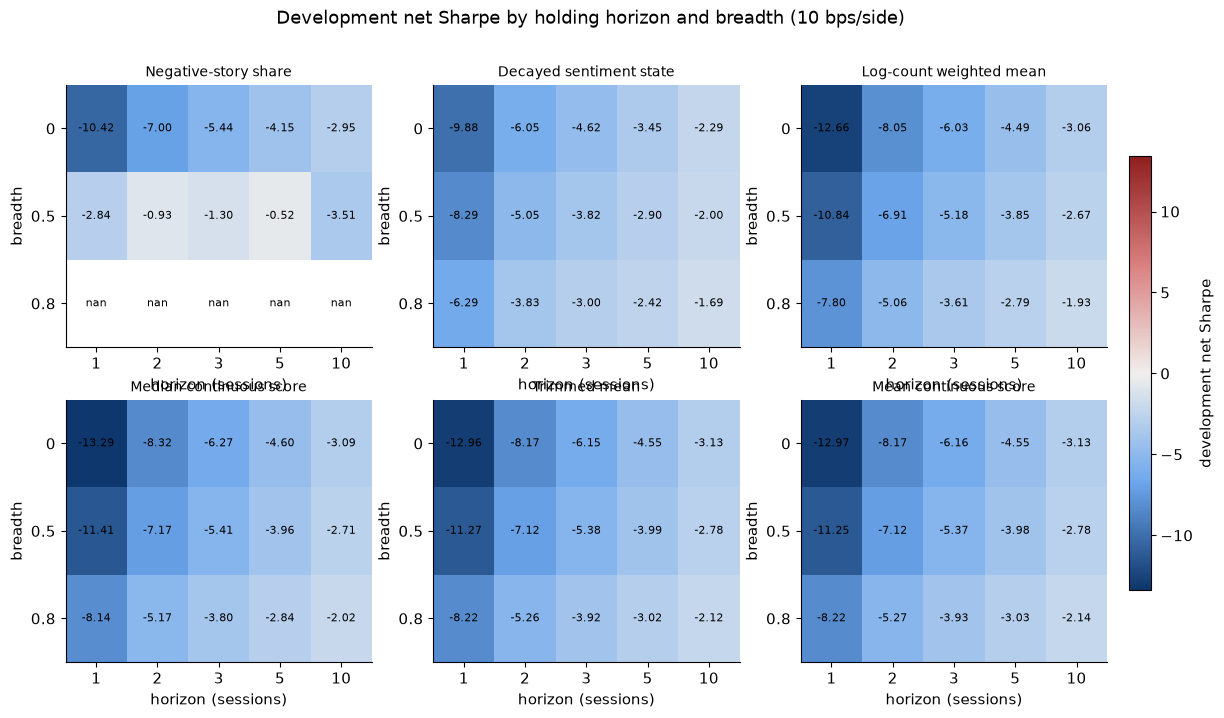

In [4]:
top_signals = (
    sweep.groupby("signal")["sharpe_net"].max().sort_values(ascending=False).head(6).index.tolist()
)
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
vmax = float(np.nanmax(np.abs(sweep["sharpe_net"])))
# Diverging scale with a NEUTRAL GREY midpoint. A yellow or green centre (as in
# RdYlGn) puts a colour at zero, which makes "no effect" read as a value.
cmap = diverging_cmap()
for ax, signal in zip(axes.ravel(), top_signals, strict=False):
    pivot = (
        sweep.loc[sweep["signal"] == signal]
        .pivot(index="breadth", columns="horizon", values="sharpe_net")
        .sort_index()
    )
    im = ax.imshow(pivot.to_numpy(), cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{b:g}" for b in pivot.index])
    ax.set_title(display_label(signal), fontsize=10)
    ax.set_xlabel("horizon (sessions)")
    ax.set_ylabel("breadth")
    ax.grid(False)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.to_numpy()[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="development net Sharpe")
fig.suptitle("Development net Sharpe by holding horizon and breadth (10 bps/side)", y=0.98)
fig.savefig(OUTPUT_DIR / "development_sharpe_surface.png", dpi=140, bbox_inches="tight")
plt.show()

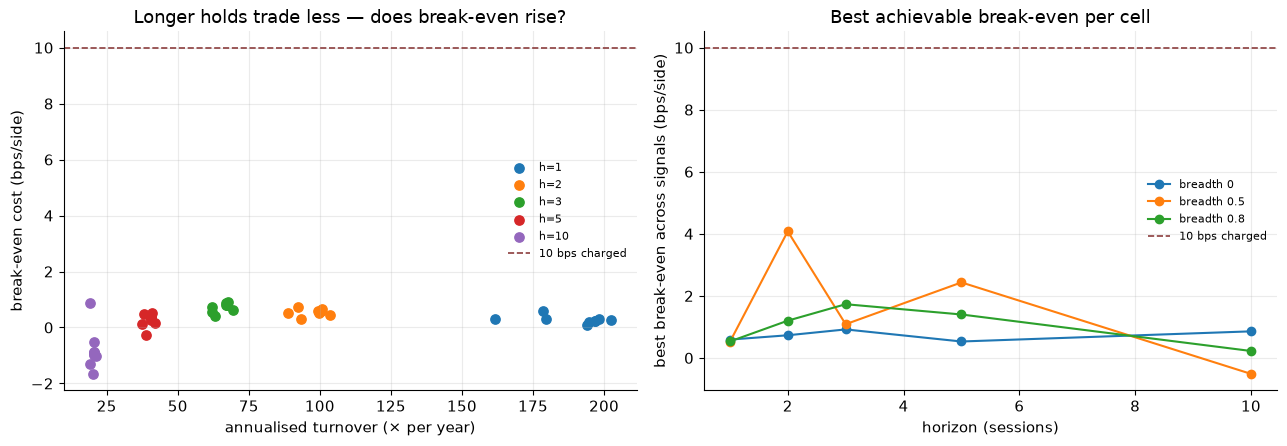

Development cells clearing 10 bps/side: 0 of 135


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for horizon in DEFAULT_HORIZONS:
    sub = sweep.loc[(sweep["horizon"] == horizon) & (sweep["breadth"] == 0.0)]
    axes[0].scatter(sub["annualized_turnover"], sub["breakeven_bps_per_side"], label=f"h={horizon}", s=45)
axes[0].axhline(COST_BPS, color="#8c3d3d", ls="--", lw=1.2, label=f"{COST_BPS:g} bps charged")
axes[0].set_xlabel("annualised turnover (× per year)")
axes[0].set_ylabel("break-even cost (bps/side)")
axes[0].set_title("Longer holds trade less — does break-even rise?")
axes[0].legend(frameon=False, fontsize=8)

best_by_cell = sweep.groupby(["horizon", "breadth"])["breakeven_bps_per_side"].max().reset_index()
for breadth in DEFAULT_BREADTHS:
    sub = best_by_cell.loc[best_by_cell["breadth"] == breadth]
    axes[1].plot(sub["horizon"], sub["breakeven_bps_per_side"], marker="o", label=f"breadth {breadth:g}")
axes[1].axhline(COST_BPS, color="#8c3d3d", ls="--", lw=1.2, label=f"{COST_BPS:g} bps charged")
axes[1].set_xlabel("horizon (sessions)")
axes[1].set_ylabel("best break-even across signals (bps/side)")
axes[1].set_title("Best achievable break-even per cell")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_breakeven_vs_horizon.png", dpi=140)
plt.show()

viable = sweep.loc[sweep["breakeven_bps_per_side"].astype(float) > COST_BPS]
print(
    f"Development cells clearing {COST_BPS:g} bps/side: {len(viable)} of {len(sweep)}"
    + (f"\n  {viable['signal'].value_counts().to_dict()}" if len(viable) else "")
)

## 2. Apply the declared selection rule, and freeze it

Highest development net Sharpe after costs, ≥250 sessions, ≥5 average
positions, ties to lower turnover. Written to disk **before** §3 runs.

In [6]:
spec = select_frozen_spec(
    sweep, criterion="sharpe_net", min_sessions=MIN_SESSIONS, min_positions=MIN_POSITIONS
)
spec.update(
    {
        "orient": float(DEFAULT_SIGNAL_ORIENT.get(spec["signal"], 1.0)),
        "cost_bps_per_side": COST_BPS,
        "min_names": MIN_NAMES,
        "position_rule": "within-session centred rank, gross 1, dollar-neutral",
        "return_convention": "dense market-adjusted open-to-open",
        "split_boundary_rule": "formation and every held return remain inside the named split",
        "grid": {"horizons": list(DEFAULT_HORIZONS), "breadths": list(DEFAULT_BREADTHS)},
        "frozen_before_evaluation_read": True,
    }
)
SPEC_PATH.write_text(json.dumps(spec, indent=2, default=str) + "\n")
print(json.dumps(spec, indent=2, default=str))
print(f"\nfrozen → {SPEC_PATH}")

{
  "signal": "decayed_state",
  "horizon": 10,
  "breadth": 0.8,
  "selection_criterion": "sharpe_net",
  "selection_split": "development",
  "eligibility": {
    "min_sessions": 250,
    "min_positions": 5.0
  },
  "development_sharpe_net": -1.6931661572634475,
  "development_mean_net": -0.0002153403861421467,
  "development_breakeven_bps_per_side": -1.729186062864619,
  "n_cells_considered": 135,
  "n_cells_eligible": 120,
  "development_end": "2019-12-31",
  "evaluation_start": "2020-01-01",
  "orient": 1.0,
  "cost_bps_per_side": 10.0,
  "min_names": 5,
  "position_rule": "within-session centred rank, gross 1, dollar-neutral",
  "return_convention": "dense market-adjusted open-to-open",
  "split_boundary_rule": "formation and every held return remain inside the named split",
  "grid": {
    "horizons": [
      1,
      2,
      3,
      5,
      10
    ],
    "breadths": [
      0.0,
      0.5,
      0.8
    ]
  },
  "frozen_before_evaluation_read": true
}

frozen → /Users/peterpr

## 3. Corrected evaluation run

The frozen spec is applied from 2020-01-01 onward without re-selection. This
is the one valid strategy evaluation read. A pre-repair read is invalidated
because development holding-period returns crossed the split boundary; it is
preserved in `INVALIDATED_RUNS.md` and is not hidden from the run count.

In [7]:
spec_on_disk = json.loads(SPEC_PATH.read_text())
evaluation = run_frozen_spec(
    agg,
    daily_ar,
    spec_on_disk,
    orients=DEFAULT_SIGNAL_ORIENT,
    cost_bps_per_side=COST_BPS,
    min_names=MIN_NAMES,
    split="evaluation",
)
development = run_backtest(
    agg,
    daily_ar,
    StrategyConfig(
        signal=spec_on_disk["signal"],
        horizon=int(spec_on_disk["horizon"]),
        breadth=float(spec_on_disk["breadth"]),
        orient=float(DEFAULT_SIGNAL_ORIENT.get(spec_on_disk["signal"], 1.0)),
        cost_bps_per_side=COST_BPS,
        min_names=MIN_NAMES,
    ),
    split="development",
)

compare = pd.DataFrame([development.summary, evaluation.summary], index=["development", "evaluation"])
show = [
    "n_sessions", "years", "mean_net", "cagr_net", "ann_vol", "sharpe_gross", "sharpe_net",
    "max_drawdown", "hit_rate", "annualized_turnover", "breakeven_bps_per_side",
    "mean_positions", "mean_net_exposure", "max_missing_weight_share",
    "bootstrap_net_ci_low", "bootstrap_net_ci_high",
]
display(compare[show].T.round(5))
compare.to_csv(OUTPUT_DIR / "development_vs_evaluation.csv")
evaluation.daily.to_csv(OUTPUT_DIR / "evaluation_daily.csv", index=False)
development.daily.to_csv(OUTPUT_DIR / "development_daily.csv", index=False)

,development,evaluation
n_sessions,2263.00000,1004.00000
years,8.98016,3.98413
mean_net,-0.00022,-0.00021
cagr_net,-0.05331,-0.05370
ann_vol,0.03205,0.05677
sharpe_gross,-0.24962,-0.13267
sharpe_net,-1.69317,-0.94373
max_drawdown,-0.39225,-0.29670
hit_rate,0.46045,0.49004
annualized_turnover,23.13280,23.02388


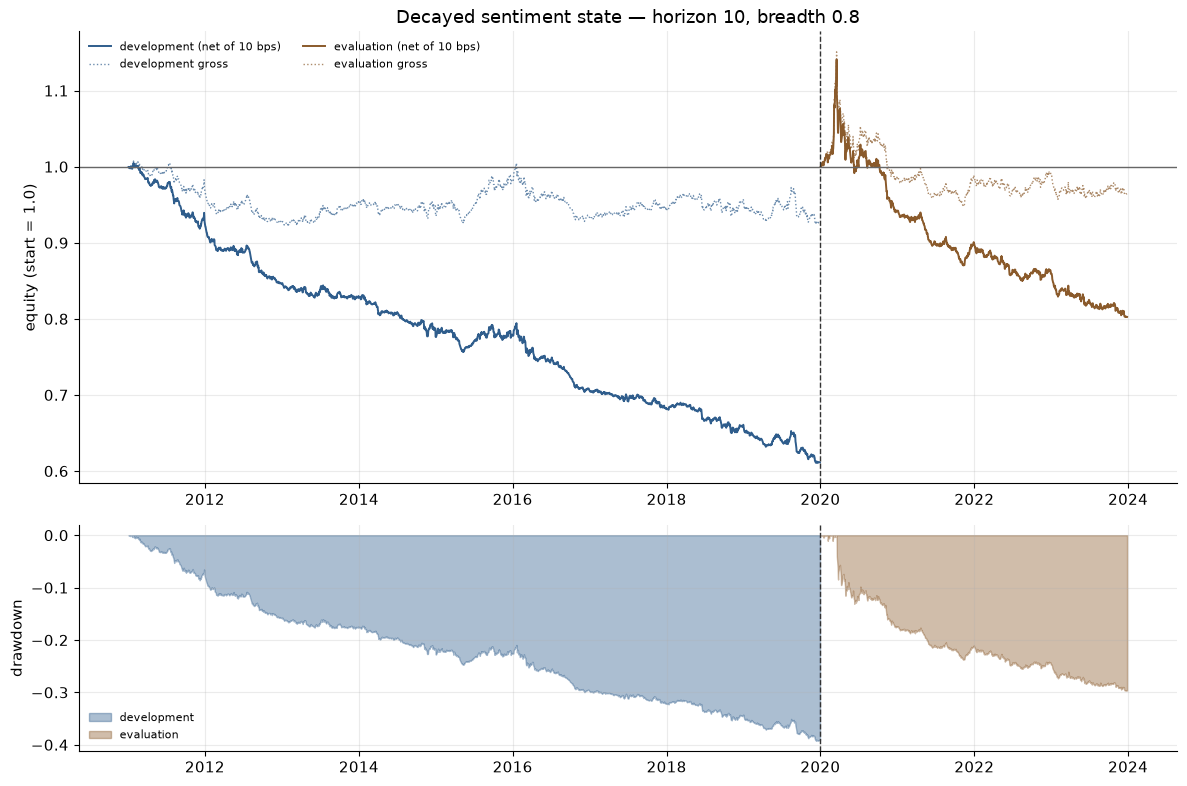

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False, gridspec_kw={"height_ratios": [2, 1]})
for label, result, colour in (
    ("development", development, "#2f5d8c"),
    ("evaluation", evaluation, "#8a5a2b"),
):
    daily = result.daily
    if daily.empty:
        continue
    equity = np.cumprod(1.0 + daily["net_return"].to_numpy(dtype=float))
    axes[0].plot(daily["session_date"], equity, color=colour, lw=1.4, label=f"{label} (net of {COST_BPS:g} bps)")
    gross_equity = np.cumprod(1.0 + daily["gross_return"].to_numpy(dtype=float))
    axes[0].plot(daily["session_date"], gross_equity, color=colour, lw=1.0, ls=":", alpha=0.7, label=f"{label} gross")
    drawdown = equity / np.maximum.accumulate(equity) - 1.0
    axes[1].fill_between(daily["session_date"], drawdown, 0.0, color=colour, alpha=0.4, label=label)

axes[0].axhline(1.0, color="#666", lw=1)
axes[0].axvline(pd.Timestamp(FROZEN_EVAL_START), color="#333", ls="--", lw=1)
axes[0].set_ylabel("equity (start = 1.0)")
axes[0].set_title(
    f"{display_label(spec_on_disk['signal'])} — horizon {spec_on_disk['horizon']}, breadth {spec_on_disk['breadth']:g}"
)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
axes[1].axvline(pd.Timestamp(FROZEN_EVAL_START), color="#333", ls="--", lw=1)
axes[1].set_ylabel("drawdown")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=140)
plt.show()

### Per year

A strategy that only works in one regime is not a strategy. 2020 in particular
is a volatility outlier and should be readable on its own.

,year,sessions,net_return,ann_vol,sharpe_net,max_drawdown,mean_turnover,split
0,2011,252,-0.0719,0.0307,-2.4118,-0.0860,0.0903,development
1,2012,250,-0.0890,0.0292,-3.1995,-0.0820,0.0935,development
2,2013,252,-0.0210,0.0257,-0.8146,-0.0253,0.0934,development
3,2014,252,-0.0620,0.0304,-2.0897,-0.0660,0.0932,development
4,2015,252,0.0020,0.0357,0.0737,-0.0405,0.0926,development
5,2016,252,-0.0925,0.0380,-2.5317,-0.1139,0.0922,development
6,2017,251,-0.0327,0.0251,-1.3151,-0.0352,0.0918,development
7,2018,251,-0.0324,0.0342,-0.9500,-0.0581,0.0897,development
8,2019,251,-0.0748,0.0365,-2.1177,-0.0702,0.0896,development
9,2020,253,-0.0581,0.0964,-0.5702,-0.1760,0.0904,evaluation


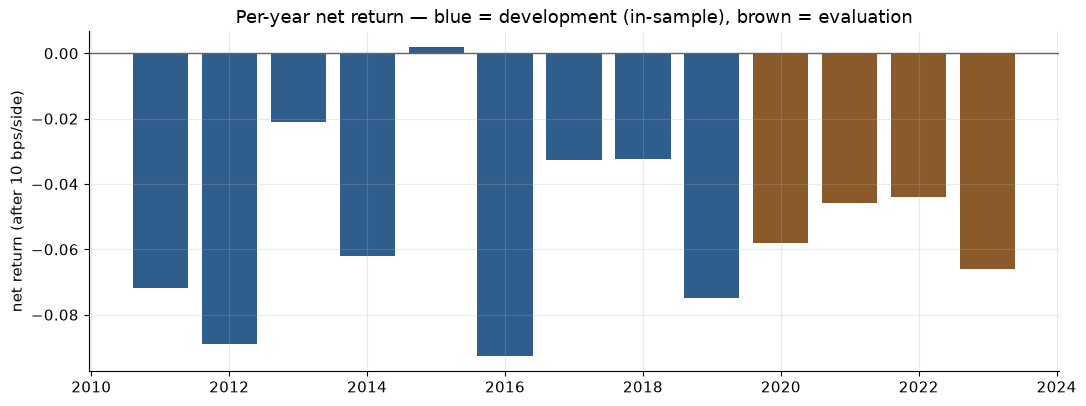

In [9]:
years = pd.concat(
    [
        yearly_table(development.daily).assign(split="development"),
        yearly_table(evaluation.daily).assign(split="evaluation"),
    ],
    ignore_index=True,
)
display(years.round(4))
years.to_csv(OUTPUT_DIR / "yearly_performance.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.2))
colours = ["#2f5d8c" if s == "development" else "#8a5a2b" for s in years["split"]]
ax.bar(years["year"], years["net_return"], color=colours)
ax.axhline(0.0, color="#666", lw=1)
ax.set_ylabel(f"net return (after {COST_BPS:g} bps/side)")
ax.set_title("Per-year net return — blue = development (in-sample), brown = evaluation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "yearly_net_return.png", dpi=140)
plt.show()

## 4. What cost kills it

Break-even is one number; the whole curve is more honest.

,cost_bps_per_side,mean_net,sharpe_net,total_return_net,split
0,0.0,-0.0000,-0.2496,-0.0736,development
1,2.0,-0.0001,-0.5383,-0.1475,development
2,5.0,-0.0001,-0.9714,-0.2474,development
3,10.0,-0.0002,-1.6932,-0.3886,development
4,15.0,-0.0003,-2.4149,-0.5033,development
5,20.0,-0.0004,-3.1366,-0.5965,development
6,30.0,-0.0006,-4.5796,-0.7337,development
7,0.0,-0.0000,-0.1327,-0.0358,evaluation
8,2.0,-0.0001,-0.2949,-0.0705,evaluation
9,5.0,-0.0001,-0.5382,-0.1203,evaluation


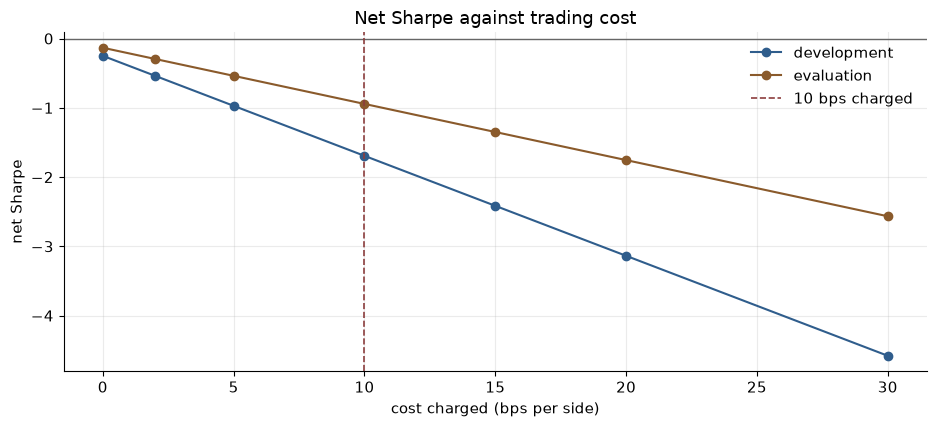

In [10]:
frozen_config = StrategyConfig(
    signal=spec_on_disk["signal"],
    horizon=int(spec_on_disk["horizon"]),
    breadth=float(spec_on_disk["breadth"]),
    orient=float(DEFAULT_SIGNAL_ORIENT.get(spec_on_disk["signal"], 1.0)),
    cost_bps_per_side=COST_BPS,
    min_names=MIN_NAMES,
)
curves = pd.concat(
    [
        cost_curve(agg, daily_ar, frozen_config, split="development").assign(split="development"),
        cost_curve(agg, daily_ar, frozen_config, split="evaluation").assign(split="evaluation"),
    ],
    ignore_index=True,
)
display(curves.round(4))
curves.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for split, colour in (("development", "#2f5d8c"), ("evaluation", "#8a5a2b")):
    sub = curves.loc[curves["split"] == split]
    ax.plot(sub["cost_bps_per_side"], sub["sharpe_net"], marker="o", color=colour, label=split)
ax.axhline(0.0, color="#666", lw=1)
ax.axvline(COST_BPS, color="#8c3d3d", ls="--", lw=1.2, label=f"{COST_BPS:g} bps charged")
ax.set_xlabel("cost charged (bps per side)")
ax.set_ylabel("net Sharpe")
ax.set_title("Net Sharpe against trading cost")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=140)
plt.show()

## 5. Verdict

In [11]:
ev = evaluation.summary
dv = development.summary
survives = bool(ev["bootstrap_net_ci_low"] > 0)
print(f"Frozen spec: {spec_on_disk['signal']}  horizon={spec_on_disk['horizon']}  breadth={spec_on_disk['breadth']:g}")
print(f"  development net Sharpe {dv['sharpe_net']:+.3f} | evaluation net Sharpe {ev['sharpe_net']:+.3f}")
print(f"  evaluation mean daily net {ev['mean_net']:+.6f}  95% CI [{ev['bootstrap_net_ci_low']:+.6f}, {ev['bootstrap_net_ci_high']:+.6f}]")
print(f"  evaluation max drawdown {ev['max_drawdown']:.1%}   hit rate {ev['hit_rate']:.1%}")
print(f"  break-even {ev['breakeven_bps_per_side']:.2f} bps/side vs {COST_BPS:g} charged")
print()
print(
    "VERDICT: evaluation net return is positive with a bootstrap CI excluding zero."
    if survives
    else "VERDICT: the strategy does not make money net of costs on the evaluation block."
)

manifest = {
    "notebook": "06_strategy",
    "built_for": "Trading-strategy test of the W3 firm-day signals",
    "frozen_spec": spec_on_disk,
    "selection_split": "development",
    "evaluation_read_history": {
        "total_reads": 2,
        "valid_reads": 1,
        "invalidated_reads": 1,
        "invalidated_reason": "pre-repair development holding periods crossed into January 2020",
    },
    "development": dv,
    "evaluation": ev,
    "cost_bps_per_side": COST_BPS,
    "grid_cells": int(len(sweep)),
    "development_cells_clearing_cost": int(len(viable)),
    "evaluation_net_ci_excludes_zero": survives,
    "caveat": (
        "Evaluation block was already opened by 04_surprise; it is a chronological "
        "evaluation block, not a pristine holdout."
    ),
    "analysis_status": "exploratory_repaired_2026-07-31",
    "supersedes": "outputs/superseded/20260731_pre_rigour_repair/06_strategy",
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n")

Frozen spec: decayed_state  horizon=10  breadth=0.8
  development net Sharpe -1.693 | evaluation net Sharpe -0.944
  evaluation mean daily net -0.000213  95% CI [-0.000422, +0.000001]
  evaluation max drawdown -29.7%   hit rate 49.0%
  break-even -1.64 bps/side vs 10 charged

VERDICT: the strategy does not make money net of costs on the evaluation block.


3978

### Carry-forward

1. The frozen spec and its selection rule are on disk; any re-run must reuse
   `frozen_spec.json` rather than re-selecting.
2. Report the development→evaluation Sharpe drop honestly — it is the size of
   the selection effect on a 135-cell grid.
3. The cost curve, not the single break-even number, is the figure to promote.